In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import PPO, DQN
from gymnasium.wrappers import RecordVideo
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import VecVideoRecorder
import os 
import do_mpc
from casadi import vertcat
from scipy.linalg import solve_discrete_are
import sys
sys.path.insert(0, os.path.abspath(os.path.join('..')))
from mpc.Cartpole_Control_Utils import *
import time

c:\Users\igrahek\AppData\Local\anaconda3\envs\shitty_bird_env\lib\site-packages\do_mpc\sysid\__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
c:\Users\igrahek\AppData\Local\anaconda3\envs\shitty_bird_env\lib\site-packages\do_mpc\opcua\__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')


## Train and evaluate the models

In [6]:
# Create 'Results' folder if it doesn't exist
results_folder = "../results/PerformanceResults/"

# Make sure the folders exist
for folder in [results_folder]:
    if not os.path.exists(folder):
        os.makedirs(folder)

# Lists for timing results
results_records = []

#------------------------------------------------------------------------------------------------------------------------------------------------
# Train/evaluate the MPC model
#------------------------------------------------------------------------------------------------------------------------------------------------
start_time = time.time()
mpc_results = evaluate_mpc_controllers(
        horizons=[60,70],
        recompute_intervals=[1, 2],
        length_ratios=[1,2],
        wind_mus=[0.0], 
        wind_sigmas=[0.0],
        results_folder="../results/PerformanceResults/",
        episode_length=600,
        num_episodes=2,
        linear=False,
        init_angles=[0.0],
        action_space='continuous'
    )



## Pole length error

Found data for horizons: [40, 50, 60, 70] steps = ['0.8s', '1.0s', '1.2s', '1.4s']
Found data for recompute intervals: [1, 2] steps = ['0.02s', '0.04s']
Plotting ratios: [1.0, 2.0]

Plot saved to: ../results/PerformanceResults/mpc_4d_performance_heatmaps_wmu0.0_wsig0.0_iang0.00_ascontinuous.png


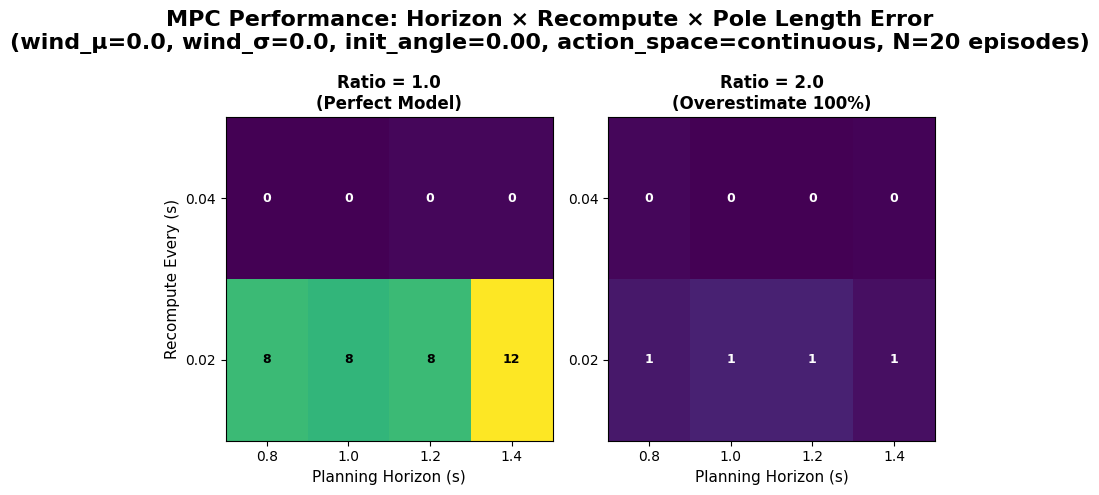

In [ ]:
plot_pole_angle_heatmaps(results_folder="../results/PerformanceResults/", 
                                length_ratios=[1.0, 2.0, 3.0, 4.0],
                                wind_mu=0.0,
                                wind_sigma=0.0,
                                action_space='continuous')

## Wind error

Found data for horizons: [10, 20] steps = ['0.2s', '0.4s']
Found data for recompute intervals: [4, 7] steps = ['0.08s', '0.14s']
Plotting wind means: [0.0]

Plot saved to: ../results/PerformanceResults/mpc_wind_mu_heatmaps_r1.0_s0.0_iang0.00_ascontinuous.png


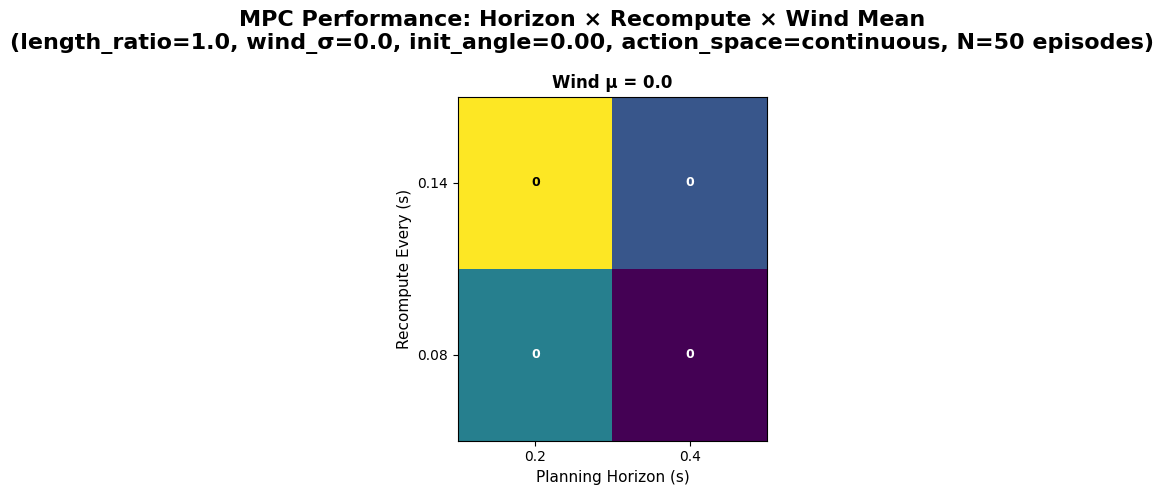

In [ ]:
plot_wind_mu_heatmaps(
    results_folder="../results/PerformanceResults/",
    wind_mus=[0.0, 0.05, 0.1, 0.15],
    length_ratio=1.0,
    wind_sigma=0.0,
    action_space='continuous'
)

## Initialization angle

Found data for horizons: [10, 20]
Found data for recompute intervals: [4, 7]
Plotting initial angles: [0.0]

Plot saved to: ../results/PerformanceResults/mpc_init_angle_heatmaps_r1.0_m0.0_s0.0_asdiscrete.png


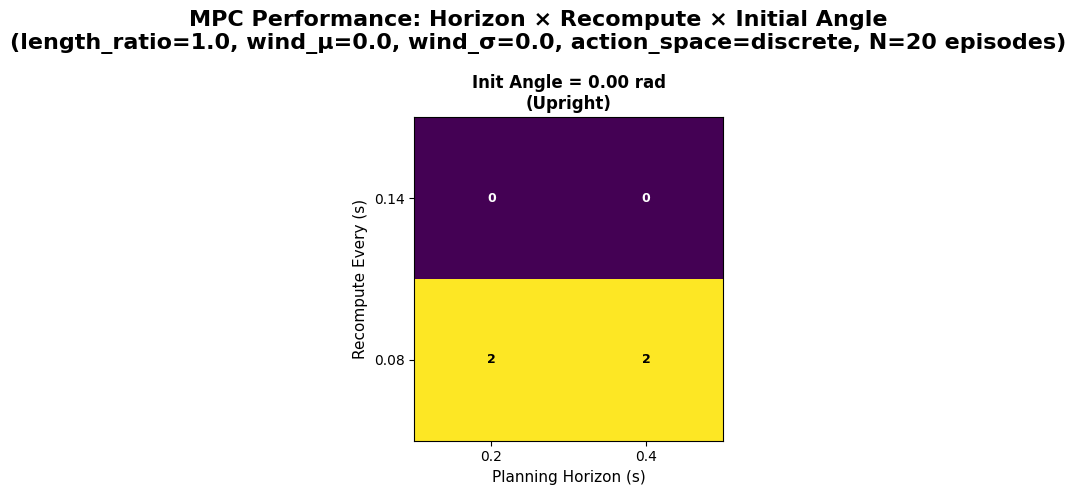

In [ ]:
# Create heatmaps for different initial angles
plot_init_angle_heatmaps(
    init_angles=[0.0, 0.05, 0.1, 0.15],
    length_ratio=1.0,
    wind_mu=0.0,
    wind_sigma=0.0,
    action_space='continuous',
)